# The Image Filter & Pixel Manipulation Engine

##### The Scenario: You are tasked with building a basic version of Photoshop using only mathematical operations.

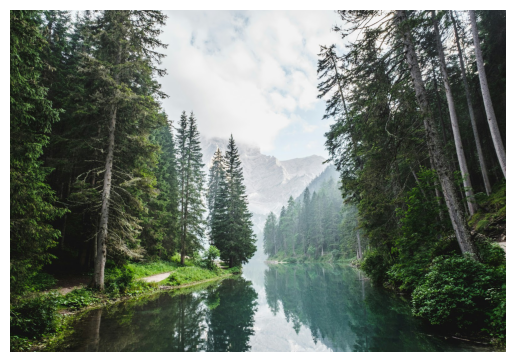

In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np 
img_array = mpimg.imread("../../image/photo2.jpg")
plt.imshow(img_array)
plt.axis('off')
plt.show()

##### Creating Arrays & Attributes: You load a provided image (using a library like matplotlib.image to read it into a NumPy array). You must inspect .shape, .ndim, and .dtype to understand how the pixels and RGB channels are structured, and create a blank "canvas" using np.zeros().

(1090, 1579, 3)
3
uint8
(1090, 1579, 3)


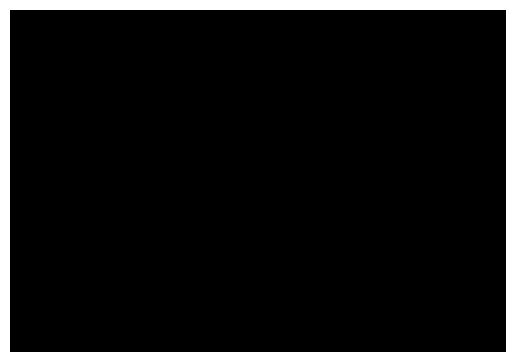

In [24]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np 
img_array = mpimg.imread("../../image/photo2.jpg")
zero_img = np.zeros_like(img_array)
print(img_array.shape)
print(img_array.ndim)
print(img_array.dtype)
print(zero_img.shape)
plt.imshow(zero_img)
plt.axis('off')
plt.show()

### Indexing, Slicing & Masking: 

##### Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 200:600]).

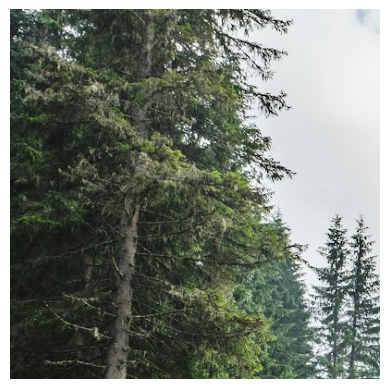

In [23]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np 
img_array = mpimg.imread("../../image/photo2.jpg")
img_crop = img_array[100:500, 200:600]
plt.imshow(img_crop)
plt.axis('off')
plt.show()

##### Indexing: Isolate only the Red channel of the image.

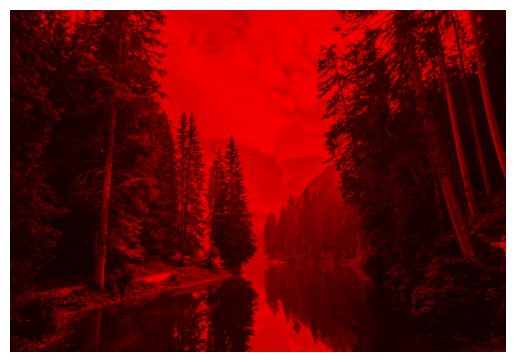

In [26]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np 
img_array = mpimg.imread("../../image/photo2.jpg")
red_img = np.zeros_like(img_array)
red_img[:,:,0] = img_array[:,:,0]
plt.imshow(red_img)
plt.axis('off')
plt.show()

##### Masking: Create a "green screen" effect. Find all pixels where the green value is high and replace them with pixels from a completely different background array.

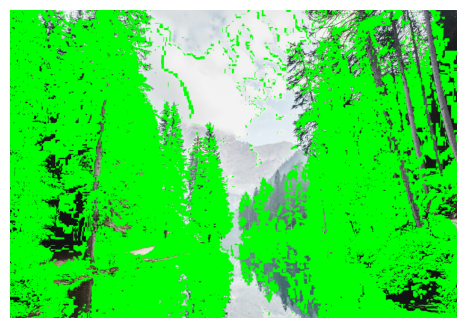

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
img = np.array(Image.open("../../image/photo2.jpg").convert("RGBA"))
mask = (img[:, :, 1] > img[:, :, 0]) & (img[:, :, 1] > img[:, :, 2])
result = img.copy()
color = np.array([0, 255, 0, 255])
result[mask] = color
plt.figure(figsize=(12, 4))
plt.imshow(result)
plt.axis("off")
plt.show()

##### Vectorization, Broadcasting & Ufuncs: Increase the image's brightness by simply adding a scalar value (e.g., img + 50 demonstrating broadcasting). Apply a gamma correction or vintage filter using np.power() and np.sqrt() (ufuncs) without writing a single for loop.

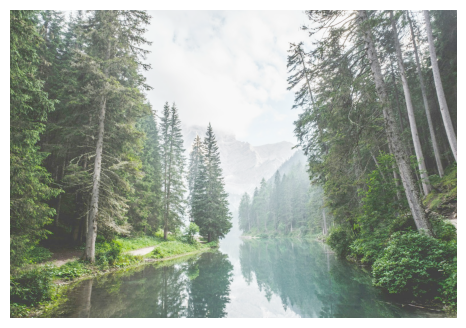

In [10]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
img_array = mpimg.imread("../../image/photo2.jpg")
bright = np.clip(img_array + 50, 0, 255)
vintage = np.sqrt(img_array / 255.0)
vintage = (vintage * 255).astype(np.uint8)
plt.figure(figsize=(12, 4))
plt.imshow(vintage.astype(np.uint8))
plt.axis("off")
plt.show()

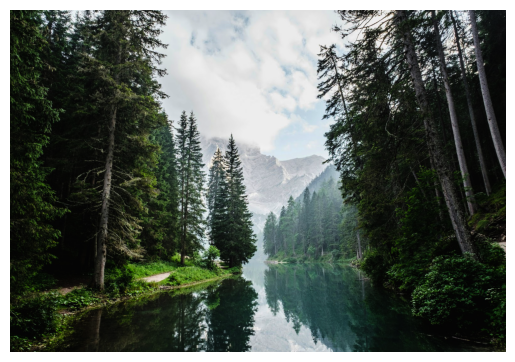

In [6]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
img_array = mpimg.imread("../../image/photo2.jpg")
gamma = 1.5
gamma_img = np.power(img_array/255.0, gamma)
gamma_img = (gamma_img * 255).astype(np.uint8)
plt.imshow(gamma_img)
plt.axis("off")
plt.show()

##### Math & Stats: Find the brightest and darkest pixels in the image (np.max, np.min). Calculate the average pixel intensity of the image to determine if it is "overexposed" or “underexposed” (np.mean across specific axes).

In [4]:
import numpy as np
from PIL import Image
img = np.array(Image.open("../../image/photo2.jpg").convert("RGBA"))
brightness = img.mean(axis=2)
max_val = np.max(brightness)
min_val = np.min(brightness)
mean_val = np.mean(img)
if mean_val > 180:
    exposure = "Overexposed"
elif mean_val < 80:
    exposure = "Underexposed"
else:
    exposure = "Well exposed"
print("Brightest value:", max_val)
print("Darkest value:", min_val)
print("Average intensity:", mean_val)
print("Exposure:", exposure)

Brightest value: 255.0
Darkest value: 63.75
Average intensity: 139.18267135743793
Exposure: Well exposed
